# 01. 데이터 통합 및 분석 (A유형 / B유형)

KCC2024·KSC2024 연구에 사용된 심리상담 챗봇 대화 데이터와 설문 데이터를 불러와 정제·통합하고, 기초 분석을 수행한다.

## 데이터 구성
- **A유형**: GPT-3.5 챗봇 참여자 (db1, db5)
- **B유형**: GPT-4.0 챗봇 참여자 (db2, db3, db4)
- 원본: carechat_2023 DB — db1~db5 대화 CSV + db1_id~db5_id 참여자 정보 CSV (총 10개)

## 주요 처리
- 중복 참여자 제거, 이름 3글자 한글 필터링, 테스트 계정 제거
- A/B유형 각각 `df_A`, `df_B` (대화), `df_A_id`, `df_B_id` (참여자 정보) 로 통합

## 분석 내용
- 참여자 성별 비율
- 사용자별 챗봇 이용 횟수 및 이용 시간대
- Turn Level 7개 지표별 평균 만족도 (A/B유형 비교)
- 종합 만족도: 사용자 평가 vs LLM 자동 평가 비교 (산점도)
- 챗봇 이용 횟수 분포
- 주관식 만족·불만족 응답 분석

---
> 참여자 개인정보 보호를 위해 식별 가능한 출력값은 제거되었습니다.  


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
db1 = pd.read_csv('C:/Users/SIZIAI/SIAIZI/reserch/chatbot/carechat_2023/data/data-1706857463786-db1-alink-4090.csv', encoding='UTF-8')
db1_id = pd.read_csv('C:/Users/SIZIAI/SIAIZI/reserch/chatbot/carechat_2023/data/data-1706857490656-db1-alink-4090.csv', encoding='cp949')
db2 = pd.read_csv('C:/Users/SIZIAI/SIAIZI/reserch/chatbot/carechat_2023/data/data-1706857046770-db2-blink-i7re.csv', encoding='UTF-8')
db2_id = pd.read_csv('C:/Users/SIZIAI/SIAIZI/reserch/chatbot/carechat_2023/data/data-1706857019453-db2-blink-i7re.csv', encoding='cp949')
db3 = pd.read_csv('C:/Users/SIZIAI/SIAIZI/reserch/chatbot/carechat_2023/data/data-1706856556270-db3-blink-4090.csv', encoding='UTF-8')
db3_id = pd.read_csv('C:/Users/SIZIAI/SIAIZI/reserch/chatbot/carechat_2023/data/data-1706856578779-db3-blink-4090.csv', encoding='cp949')
db4 = pd.read_csv('C:/Users/SIZIAI/SIAIZI/reserch/chatbot/carechat_2023/data/data-1706820611839-db4-blink-i7.csv', encoding='cp949')
db4_id = pd.read_csv('C:/Users/SIZIAI/SIAIZI/reserch/chatbot/carechat_2023/data/data-1706820632296-db4-blink-i7.csv', encoding='cp949')
db5 = pd.read_csv('C:/Users/SIZIAI/SIAIZI/reserch/chatbot/carechat_2023/data/data-1706858472354-db5-alink-ato.csv', encoding='UTF-8')
db5_id = pd.read_csv('C:/Users/SIZIAI/SIAIZI/reserch/chatbot/carechat_2023/data/data-1706858483117-db5-alink-ato.csv', encoding='cp949')

# 데이터 통합 (A유형/B유형)

## A유형 

    GPT3.5 버전을 쓴 데이터베이스들 통합 (db1, db5)

In [4]:
db1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1247 entries, 0 to 1246
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id_msg    1247 non-null   int64 
 1   username  1247 non-null   object
 2   person    1246 non-null   object
 3   chatbot   1247 non-null   object
dtypes: int64(1), object(3)
memory usage: 39.1+ KB


In [5]:
db5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id_msg    170 non-null    int64 
 1   username  170 non-null    object
 2   person    169 non-null    object
 3   chatbot   170 non-null    object
dtypes: int64(1), object(3)
memory usage: 5.4+ KB


In [ ]:
df_A = pd.concat([db1, db5], axis=0)   # GPT3.5
df_A_id = pd.concat([db1_id, db5_id], axis=0)
df_A

### df_A_id (유형A 참여자 정보) 

    영어, 이상한 username을 가진 행 제거 
    df_A_id 에서는 이름이 같은 사람은 한 행만 남겨두고 제거

In [ ]:
df_A_id['username'].unique()

In [ ]:
df_A_id['username'] = df_A_id['username'].str.strip()    # 공백 제거 (공백있는 문자열 확인 됨.)
df_A_id = df_A_id.drop_duplicates(subset=['username'], keep='first')    # 이름이 같은 사람. 처음 행 하나 빼고 제거 
df_A_id = df_A_id[df_A_id['username'].apply(lambda x: len(x) == 3 and all(ord('가') <= ord(c) <= ord('힣') for c in x))]  # username이 세 글자 한글인 행만 select 
df_A_id = df_A_id[df_A_id['username']!='테스트']    # '테스트' 제거
df_A_id = df_A_id[df_A_id['username']!='문혈순']    # 문형순과 생년월일이 같음. 이름 오타 추정. 
df_A_id = df_A_id.reset_index(drop=True)
df_A_id

# --> 총 35명 

### df_A (챗봇과의 대화)

In [ ]:
df_A['username'].unique()

In [ ]:
df_A['username'] = df_A['username'].str.strip()    # 공백 제거
df_A = df_A[df_A['username'].apply(lambda x: len(x) == 3 and all(ord('가') <= ord(c) <= ord('힣') for c in x))]  # 한글 세 글자인 행만 가져옴
df_A = df_A.reset_index(drop=True)
df_A

In [ ]:
df_A['username'].unique()   # df_A_id는 35개인데 df_A에 있는 username 은 36종류 

In [12]:
df_A.loc[df_A['username'] == '문혈순', 'username'] = '문형순'  # 문혈순을 문형순으로 바꿈

In [ ]:
df_A['username'].unique()

## B유형

In [14]:
db2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 927 entries, 0 to 926
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id_msg    927 non-null    int64 
 1   username  927 non-null    object
 2   person    927 non-null    object
 3   chatbot   927 non-null    object
 4   date      927 non-null    object
dtypes: int64(1), object(4)
memory usage: 36.3+ KB


In [15]:
db3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 471 entries, 0 to 470
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id_msg    471 non-null    int64 
 1   username  471 non-null    object
 2   person    470 non-null    object
 3   chatbot   471 non-null    object
dtypes: int64(1), object(3)
memory usage: 14.8+ KB


In [16]:
db4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id_msg    81 non-null     int64 
 1   username  81 non-null     object
 2   person    80 non-null     object
 3   chatbot   81 non-null     object
 4   date      81 non-null     object
dtypes: int64(1), object(4)
memory usage: 3.3+ KB


    GPT4.0 버전을 쓴 데이터베이스들 통합 

In [ ]:
df_B = pd.concat([db2, db3, db4], axis=0)   # GPT3.5
df_B_id = pd.concat([db2_id, db3_id, db4_id], axis=0)
df_B

    db3에는 date column이 안 들어가있기 때문에 null값으로 들어가있음 

In [18]:
df_B['date'].isnull().sum()

471

### df_B_id (유형B 참여자 정보)

    영어, 이상한 username을 가진 행 제거 
    df_B_id 에서는 이름이 같은 사람은 한 행만 남겨두고 제거

In [ ]:
df_B_id['username'].unique()

In [ ]:
df_B_id['username'] = df_B_id['username'].str.strip()    # 공백 제거
df_B_id = df_B_id.drop_duplicates(subset=['username'], keep='first')   # username이 같은 행들 중 첫번째만 남기고 제거 
df_B_id = df_B_id[df_B_id['username'].apply(lambda x: ((len(x) == 3) or (len(x)==2)) and all(ord('가') <= ord(c) <= ord('힣') for c in x))]  # 한글 세 글자만 가져옴
df_B_id = df_B_id[df_B_id['username']!='테스트']  # 테스트 제거
df_B_id = df_B_id[df_B_id['username']!='승혁']  # 승혁 제거
df_B_id.loc[df_B_id['username'] == '정성민', 'birth'] = XXXXXXXX    # 양식에 맞지 않게 쓴 값 고쳐줌. 
df_B_id.loc[df_B_id['username'] == '장민희', 'birth'] = XXXXXXXX    # 개인정보 비식별화 (github)
df_B_id = df_B_id.reset_index(drop=True)
df_B_id

### df_B (챗봇과의 대화)

In [ ]:
df_B['username'] = df_B['username'].str.strip()
df_B = df_B[df_B['username'].apply(lambda x: ((len(x) == 3) or (len(x)==2)) and all(ord('가') <= ord(c) <= ord('힣') for c in x))]
df_B = df_B[df_B['username']!='테스트']
df_B = df_B[df_B['username']!='승혁']
df_B = df_B.reset_index(drop=True)
df_B

In [ ]:
df_B['username'].unique()    # df_B_id에만 '서나영'

In [29]:
df_A.to_csv('df_A.csv')
df_A_id.to_csv('df_A_id.csv')
df_B.to_csv('df_B.csv')
df_B_id.to_csv('df_B_id.csv')

# 데이터분석 

In [25]:
df_A_survey = pd.read_excel('C:/Users/SIZIAI/SIAIZI/reserch/chatbot/carechat_2023/data/(A유형) 고민과 매칭된이야기 평가지(응답)의 폰번호제거.xlsx')
df_B_survey = pd.read_excel('C:/Users/SIZIAI/SIAIZI/reserch/chatbot/carechat_2023/data/(B유형) 고민과 매칭된이야기 평가지(응답)의 폰번호제거.xlsx')

## 챗봇 채팅에는 있고 설문에는 없는 이름 

### A유형

In [26]:
len(sorted(df_A['username'].unique()))

35

In [27]:
len(sorted(df_A_id['username'].unique()))

35

In [28]:
len(sorted(df_A_survey['이름'].unique()))

33

In [29]:
set(sorted(df_A_id['username'].unique())) - set(sorted(df_A_survey['이름'].unique()))

{'고아름', '김은영', '유지순', '정단비'}

In [30]:
set(sorted(df_A_survey['이름'].unique())) - set(sorted(df_A_id['username'].unique()))

{'문예림 ', '이승빈 '}

### B유형

In [31]:
len(sorted(df_B['username'].unique()))

41

In [32]:
len(sorted(df_B_id['username'].unique()))

42

In [33]:
set(sorted(df_B_id['username'].unique())) - set(sorted(df_B['username'].unique()))  # 서나영

{'서나영'}

In [34]:
set(sorted(df_B_id['username'].unique())) - set(sorted(df_B_survey['이름'].unique()))

{'권순찬', '김윤희', '서나영', '소정아', '안은정', '정성민', '정주현'}

In [35]:
set(sorted(df_B_survey['이름'].unique())) - set(sorted(df_B_id['username'].unique()))

{'윤정'}

## 설문자들 성별

### A유형

In [ ]:
df_A_survey.iloc[:,[1,3]]

In [37]:
df_A_survey.iloc[:, 3].value_counts()

성별 (신체적 , 정서적 모두 고려) 설명에 가까운 것을 선택해주세요.\n\n<보기>\n0: 신체적 남성, 정서적 남성\n1: 신체적 여성, 정서적 여성\n2: 신체적 여성, 정서적 남성\n3: 신체적 남성, 정서적 여성
1    221
0     18
Name: count, dtype: int64

### B유형

In [ ]:
df_B_survey.iloc[:,[1,3]]

In [39]:
df_B_survey.iloc[:, 3].value_counts().sort_index()

성별 (신체적 , 정서적 모두 고려) 설명에 가까운 것을 선택해주세요.\n\n<보기>\n0: 신체적 남성, 정서적 남성\n1: 신체적 여성, 정서적 여성\n2: 신체적 여성, 정서적 남성\n3: 신체적 남성, 정서적 여성
0     39
1    176
2     25
3     14
Name: count, dtype: int64

## 사용자별 챗봇 이용 횟수 (채팅 수로 측정)

### A유형

In [ ]:
username_counts = df_A['username'].value_counts()
username_counts

C:\Users\SIZIAI\AppData\Local\Temp\ipykernel_15804\2435621228.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=username_counts.index, y=username_counts.values, palette="husl")


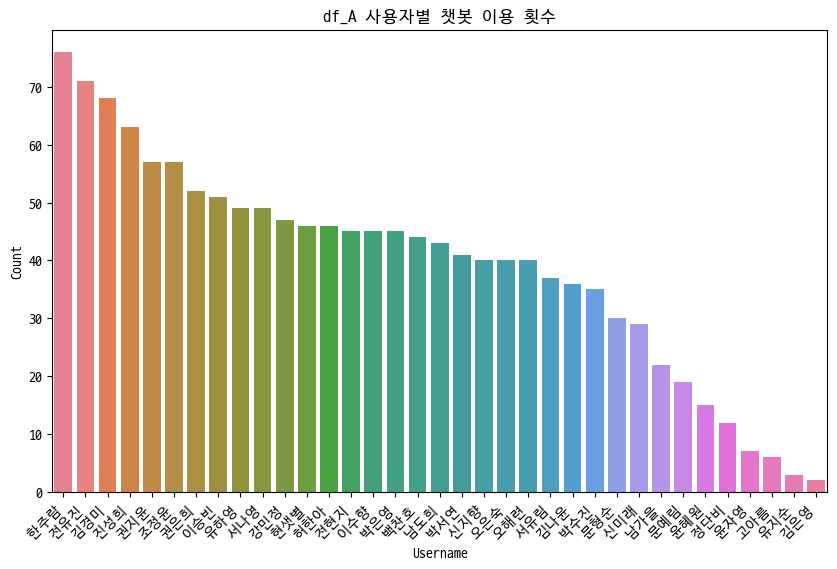

In [41]:
plt.figure(figsize=(10, 6))
plt.rcParams['font.family'] = 'D2Coding'
sns.barplot(x=username_counts.index, y=username_counts.values, palette="husl")
plt.xticks(rotation=45, ha='right')  # x축 레이블 회전
plt.xlabel('Username')
plt.ylabel('Count')
plt.title('df_A 사용자별 챗봇 이용 횟수')
plt.show()

### B유형

In [ ]:
username_counts = df_B['username'].value_counts()
username_counts

C:\Users\SIZIAI\AppData\Local\Temp\ipykernel_15804\1303128912.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=username_counts.index, y=username_counts.values, palette="husl")


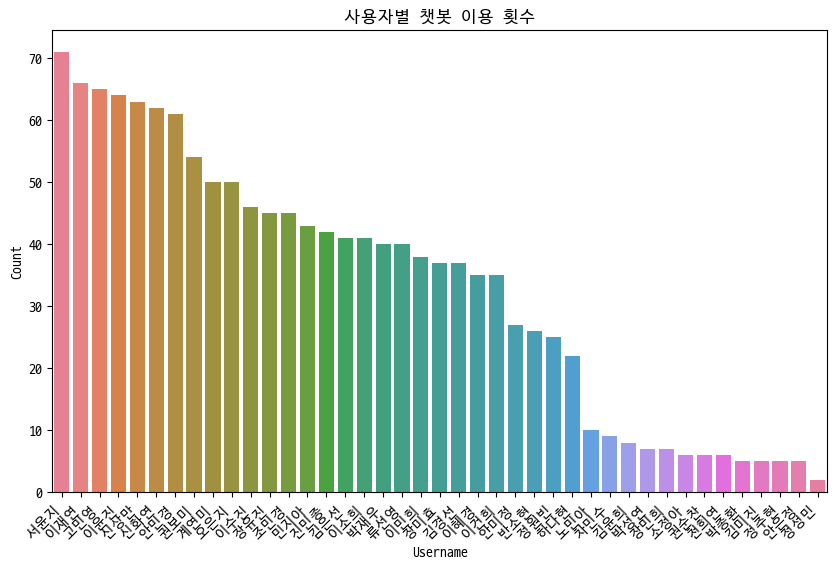

In [43]:
plt.figure(figsize=(10, 6))
sns.barplot(x=username_counts.index, y=username_counts.values, palette="husl")
plt.xticks(rotation=45, ha='right')  # x축 레이블 회전
plt.xlabel('Username')
plt.ylabel('Count')
plt.title('사용자별 챗봇 이용 횟수')
plt.show()

## 사용자들의 챗봇 이용 시간대 

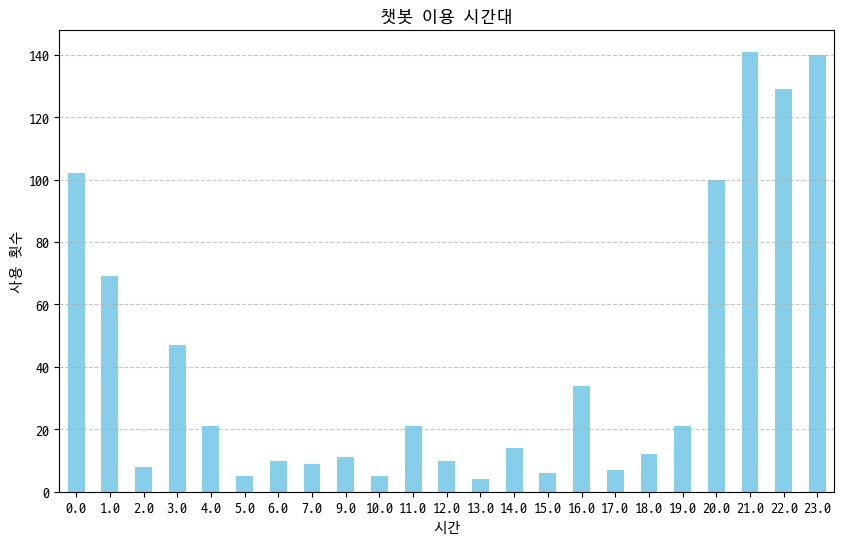

In [44]:
dfB = df_B.copy()
dfB['date'] = pd.to_datetime(dfB['date'])  # 날짜와 시간 형식으로 변환 
dfB['hour'] = dfB['date'].dt.hour    # 시간 정보 가져옴
activity_by_hour = dfB.groupby('hour').size()    # 시간대별 이용자 수 

plt.figure(figsize=(10, 6))
activity_by_hour.plot(kind='bar', color='skyblue')
plt.xlabel('시간')
plt.ylabel('사용 횟수')
plt.title('챗봇 이용 시간대')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 설문지 분석 

## 7가지 지표에 대한 평균 만족도

### 유형A

In [ ]:
df_A_survey

In [46]:
df_A_survey.columns

Index(['타임스탬프', '이름', '생년월일 8자리 (Ex. 20231218)',
       '성별 (신체적 , 정서적 모두 고려) 설명에 가까운 것을 선택해주세요.\n\n<보기>\n0: 신체적 남성, 정서적 남성\n1: 신체적 여성, 정서적 여성\n2: 신체적 여성, 정서적 남성\n3: 신체적 남성, 정서적 여성',
       '이 곳에 캡쳐본을 모두 업로드해주세요!\n\n파일명을 '이름_연락처끝4자리_날짜'로 맞춰주세요!\nex) 홍길동_1234_20231220',
       '매칭된이야기는 "적어주신 고민"의 맥락과 이어지는 "해결 방법을 올바르게" 제시하였는지, 보기에서 몇점일까요?\n\n< 보기 >\n1점 : 완전 올바르지 않은 답변\n2점 : 조금 올바르지 않은 답변\n3점 : 중간 (올바른 정도가 판단안되는 답변)\n4점 : 조금 올바른 답변\n5점 : 완전 올바른 답변',
       '매칭된이야기는 "적어주신 고민"의 맥락과 이어지는 답변을 "강압적이 아닌 설득하는 표현"을 통해 제시하는지, 보기에서 몇점일까요?\n\n< 보기 >\n1점 : 많이 강압적 답변\n2점 : 조금 강압적 답변\n3점 : 중간 (강압적인 정도가 판단안되는) 답변\n4점 : 조금 마음을 헤야려 설득하는 답변\n5점 : 많이 마음을 헤아려 설득하는 답변',
       '매칭된이야기는 "적어주신 고민"의 맥락과 이어지는 답변을 "부드러운 태도"를 통해 이야기를 마무리하는지, 보기에서 몇점일까요?\n\n< 보기 >\n1점 : 완전 딱딱한 답변\n2점 : 조금 딱딱한 답변\n3점 : 중간 (부드러운 정도가 판단안되는) 답변\n4점 : 조금 부드러운 답변\n5점 : 완전부드러운 답변',
       '매칭된이야기는  참여자분께 "혼자만의 고민이 아닌 느낌"이나 다른 사연으로 "위안 드릴 수 있었는지" 선택 부탁드려요\n\n< 보기 >\n1점 : 완전 위안 안됨\n2점 : 별로 위안 안됨\n3점 : 중간 (위안 판단안되는) 답변\n4점 : 조금 위안됨\n5점 : 완전 

In [47]:
df_A_survey['1_mean'] = df_A_survey.iloc[:, [5,12,19]].mean(axis=1)
df_A_survey['2_mean'] = df_A_survey.iloc[:, [6,13,20]].mean(axis=1)
df_A_survey['3_mean'] = df_A_survey.iloc[:, [7,14,21]].mean(axis=1)
df_A_survey['4_mean'] = df_A_survey.iloc[:, [8,15,22]].mean(axis=1)
df_A_survey['5_mean'] = df_A_survey.iloc[:, [9,16,23]].mean(axis=1)
df_A_survey['6_mean'] = df_A_survey.iloc[:, [10,17,24]].mean(axis=1)
df_A_survey['7_mean'] = df_A_survey.iloc[:, [11,18,25]].mean(axis=1)

In [48]:
df_A_survey.iloc[:,-7:]

,1_mean,2_mean,3_mean,4_mean,5_mean,6_mean,7_mean
0,4.333333,3.666667,1.666667,1.666667,3.000000,1.000000,0.666667
1,3.000000,4.000000,3.666667,3.000000,2.000000,0.666667,1.000000
2,4.333333,3.333333,3.333333,2.333333,2.666667,1.000000,1.000000
3,4.333333,4.666667,4.666667,3.666667,2.000000,1.000000,1.000000
4,4.333333,4.000000,5.000000,3.000000,2.666667,1.000000,1.000000
...,...,...,...,...,...,...,...
234,5.000000,4.000000,4.666667,4.000000,3.000000,1.000000,1.000000
235,4.000000,3.666667,4.000000,4.000000,0.333333,1.000000,1.000000
236,4.333333,3.666667,3.666667,3.666667,3.000000,1.000000,1.000000
237,4.333333,4.666667,5.000000,3.666667,2.666667,1.000000,1.000000


In [49]:
df_A_survey.to_excel('A_survey_mean.xlsx')

In [50]:
A_survey = pd.read_excel('C:/Users/SIZIAI/SIAIZI/reserch/chatbot/A_survey_mean.xlsx')
A_survey.iloc[:, -7:]

,1_mean,2_mean,3_mean,4_mean,5_mean,6_mean,7_mean
0,4.333333,3.666667,1.666667,1.666667,3.000000,1.000000,0.666667
1,3.000000,4.000000,3.666667,3.000000,2.000000,0.666667,1.000000
2,4.333333,3.333333,3.333333,2.333333,2.666667,1.000000,1.000000
3,4.333333,4.666667,4.666667,3.666667,2.000000,1.000000,1.000000
4,4.333333,4.000000,5.000000,3.000000,2.666667,1.000000,1.000000
...,...,...,...,...,...,...,...
234,5.000000,4.000000,4.666667,4.000000,3.000000,1.000000,1.000000
235,4.000000,3.666667,4.000000,4.000000,0.333333,1.000000,1.000000
236,4.333333,3.666667,3.666667,3.666667,3.000000,1.000000,1.000000
237,4.333333,4.666667,5.000000,3.666667,2.666667,1.000000,1.000000


In [51]:
A_survey['6_mean'] = A_survey['6_mean'].apply(lambda x: 1 if x >= 0.5 else 0)
A_survey['7_mean'] = A_survey['7_mean'].apply(lambda x: 1 if x >= 0.5 else 0)

In [52]:
A_survey.iloc[:, -7:]

,1_mean,2_mean,3_mean,4_mean,5_mean,6_mean,7_mean
0,4.333333,3.666667,1.666667,1.666667,3.000000,1,1
1,3.000000,4.000000,3.666667,3.000000,2.000000,1,1
2,4.333333,3.333333,3.333333,2.333333,2.666667,1,1
3,4.333333,4.666667,4.666667,3.666667,2.000000,1,1
4,4.333333,4.000000,5.000000,3.000000,2.666667,1,1
...,...,...,...,...,...,...,...
234,5.000000,4.000000,4.666667,4.000000,3.000000,1,1
235,4.000000,3.666667,4.000000,4.000000,0.333333,1,1
236,4.333333,3.666667,3.666667,3.666667,3.000000,1,1
237,4.333333,4.666667,5.000000,3.666667,2.666667,1,1


In [53]:
A_survey.to_excel('A_survey_mean.xlsx')

In [54]:
A_survey_mean = A_survey.iloc[:, -7:]

In [55]:
A_survey_mean.to_excel('A_survey_only_mean.xlsx')

### 유형B

In [ ]:
df_B_survey

In [57]:
df_B_survey.columns

Index(['타임스탬프', '이름', '생년월일 8자리 (Ex. 20231218)',
       '성별 (신체적 , 정서적 모두 고려) 설명에 가까운 것을 선택해주세요.\n\n<보기>\n0: 신체적 남성, 정서적 남성\n1: 신체적 여성, 정서적 여성\n2: 신체적 여성, 정서적 남성\n3: 신체적 남성, 정서적 여성',
       '이 곳에 캡쳐본을 모두 업로드해주세요!\n\n파일명을 '이름_연락처끝4자리_날짜'로 맞춰주세요!\nex) 홍길동_1234_20231220',
       '매칭된이야기는 "적어주신 고민"의 맥락과 이어지는 "해결 방법을 올바르게" 제시하였는지, 보기에서 몇점일까요?\n\n< 보기 >\n1점 : 완전 올바르지 않은 답변\n2점 : 조금 올바르지 않은 답변\n3점 : 중간 (올바른 정도가 판단안되는 답변)\n4점 : 조금 올바른 답변\n5점 : 완전 올바른 답변',
       '매칭된이야기는 "적어주신 고민"의 맥락과 이어지는 답변을 "강압적이 아닌 설득하는 표현"을 통해 제시하는지, 보기에서 몇점일까요?\n\n< 보기 >\n1점 : 많이 강압적 답변\n2점 : 조금 강압적 답변\n3점 : 중간 (강압적인 정도가 판단안되는) 답변\n4점 : 조금 마음을 헤야려 설득하는 답변\n5점 : 많이 마음을 헤아려 설득하는 답변',
       '매칭된이야기는 "적어주신 고민"의 맥락과 이어지는 답변을 "부드러운 태도"를 통해 이야기를 마무리하는지, 보기에서 몇점일까요?\n\n< 보기 >\n1점 : 완전 딱딱한 답변\n2점 : 조금 딱딱한 답변\n3점 : 중간 (부드러운 정도가 판단안되는) 답변\n4점 : 조금 부드러운 답변\n5점 : 완전부드러운 답변',
       '매칭된이야기는  참여자분께 "혼자만의 고민이 아닌 느낌"이나 다른 사연으로 "위안 드릴 수 있었는지" 선택 부탁드려요\n\n< 보기 >\n1점 : 완전 위안 안됨\n2점 : 별로 위안 안됨\n3점 : 중간 (위안 판단안되는) 답변\n4점 : 조금 위안됨\n5점 : 완전 

In [58]:
df_B_survey['1_mean'] = df_B_survey.iloc[:, [5,12,19]].mean(axis=1)
df_B_survey['2_mean'] = df_B_survey.iloc[:, [6,13,20]].mean(axis=1)
df_B_survey['3_mean'] = df_B_survey.iloc[:, [7,14,21]].mean(axis=1)
df_B_survey['4_mean'] = df_B_survey.iloc[:, [8,15,22]].mean(axis=1)
df_B_survey['5_mean'] = df_B_survey.iloc[:, [9,16,23]].mean(axis=1)
df_B_survey['6_mean'] = df_B_survey.iloc[:, [10,17,24]].mean(axis=1)
df_B_survey['7_mean'] = df_B_survey.iloc[:, [11,18,25]].mean(axis=1)

In [59]:
df_B_survey.iloc[:,-7:]

,1_mean,2_mean,3_mean,4_mean,5_mean,6_mean,7_mean
0,3.000000,2.666667,3.000000,3.000000,2.000000,1.0,1.0
1,5.000000,5.000000,5.000000,3.000000,3.000000,1.0,1.0
2,4.333333,4.333333,4.333333,3.666667,2.666667,1.0,1.0
3,3.666667,4.666667,4.333333,4.333333,3.000000,1.0,1.0
4,4.000000,4.000000,4.000000,1.666667,2.333333,1.0,1.0
...,...,...,...,...,...,...,...
249,5.000000,5.000000,5.000000,5.000000,3.000000,1.0,1.0
250,4.000000,3.333333,2.333333,3.333333,2.000000,1.0,1.0
251,5.000000,5.000000,5.000000,5.000000,3.000000,1.0,1.0
252,3.000000,3.333333,3.333333,2.666667,3.000000,1.0,1.0


In [60]:
df_B_survey.to_excel('B_survey_mean.xlsx')

In [61]:
B_survey = pd.read_excel('C:/Users/SIZIAI/SIAIZI/reserch/chatbot/B_survey_mean.xlsx')
B_survey.iloc[:, -7:]

,1_mean,2_mean,3_mean,4_mean,5_mean,6_mean,7_mean
0,3.000000,2.666667,3.000000,3.000000,2.000000,1.0,1.0
1,5.000000,5.000000,5.000000,3.000000,3.000000,1.0,1.0
2,4.333333,4.333333,4.333333,3.666667,2.666667,1.0,1.0
3,3.666667,4.666667,4.333333,4.333333,3.000000,1.0,1.0
4,4.000000,4.000000,4.000000,1.666667,2.333333,1.0,1.0
...,...,...,...,...,...,...,...
249,5.000000,5.000000,5.000000,5.000000,3.000000,1.0,1.0
250,4.000000,3.333333,2.333333,3.333333,2.000000,1.0,1.0
251,5.000000,5.000000,5.000000,5.000000,3.000000,1.0,1.0
252,3.000000,3.333333,3.333333,2.666667,3.000000,1.0,1.0


In [62]:
B_survey['6_mean'] = B_survey['6_mean'].apply(lambda x: 1 if x >= 0.5 else 0)
B_survey['7_mean'] = B_survey['7_mean'].apply(lambda x: 1 if x >= 0.5 else 0)

In [63]:
B_survey.iloc[:, -7:]

,1_mean,2_mean,3_mean,4_mean,5_mean,6_mean,7_mean
0,3.000000,2.666667,3.000000,3.000000,2.000000,1,1
1,5.000000,5.000000,5.000000,3.000000,3.000000,1,1
2,4.333333,4.333333,4.333333,3.666667,2.666667,1,1
3,3.666667,4.666667,4.333333,4.333333,3.000000,1,1
4,4.000000,4.000000,4.000000,1.666667,2.333333,1,1
...,...,...,...,...,...,...,...
249,5.000000,5.000000,5.000000,5.000000,3.000000,1,1
250,4.000000,3.333333,2.333333,3.333333,2.000000,1,1
251,5.000000,5.000000,5.000000,5.000000,3.000000,1,1
252,3.000000,3.333333,3.333333,2.666667,3.000000,1,1


In [64]:
B_survey.to_excel('B_survey_mean.xlsx')

In [65]:
B_survey_mean = B_survey.iloc[:, -7:]

In [66]:
B_survey_mean.to_excel('B_survey_only_mean.xlsx')

## 종합 만족도 

In [68]:
df_A_survey = pd.read_excel('C:/Users/SIZIAI/SIAIZI/reserch/chatbot/carechat_2023/data/(A유형) 고민과 매칭된이야기 평가지(응답)의 폰번호제거.xlsx')
df_B_survey = pd.read_excel('C:/Users/SIZIAI/SIAIZI/reserch/chatbot/carechat_2023/data/(B유형) 고민과 매칭된이야기 평가지(응답)의 폰번호제거.xlsx')

### 유형A

#### 설문자들의 종합만족도

In [69]:
A_survey = df_A_survey.copy()

In [ ]:
A_survey_name = A_survey.iloc[:,[1, -7]].sort_values(by='이름')
A_survey_name

In [ ]:
A_survey_name_score = A_survey_name.groupby(['이름']).mean()
A_survey_name_score.rename(columns={'[1] 세 번의 매칭된이야기 사용 경험에 대한 종합 "만족도" 점수를 부탁드립니다.\n\n< 보기 >\n1점 : 완전 의미없음\n2점 : 별로 의미없음\n3점 : 중간\n4점 : 조금 의미있었음\n5점 : 완전 의미있었음': 'score'}, inplace=True)
A_survey_name_score

#### 챗봇이 설문자의 입장에서 평가한 종합 만족도

In [ ]:
df_A_chat = pd.read_csv('C:/Users/SIZIAI/SIAIZI/reserch/chatbot/df_A_chat.csv')
df_A_chat.sort_values(by='username', inplace=True)
df_A_name = df_A_chat.iloc[:, [1,-1]]
df_chat_name_score = df_A_name.groupby(['username']).mean()
df_chat_name_score

#### concat 후, 산점도

In [73]:
 set(sorted(A_survey_name_score.index.unique())) - set(sorted(df_chat_name_score.index.unique()))

{'문예림 ', '이승빈 '}

In [74]:
set(sorted(df_chat_name_score.index.unique())) - set(sorted(A_survey_name_score.index.unique()))

{'고아름', '김은영', '유지순', '정단비'}

In [ ]:
df_A_con = pd.concat([df_chat_name_score, A_survey_name_score], axis=1)
df_A_con.drop(['고아름', '김은영','유지순','정단비'], inplace=True)
df_A_con = df_A_con.iloc[:-2]
df_A_con

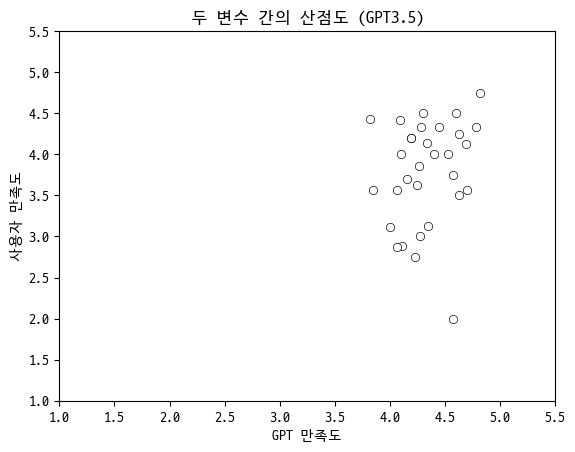

In [76]:
_=sns.scatterplot(x = df_A_con.iloc[:, 0], y = df_A_con.iloc[:, 1], color=['white'], edgecolor=['black'])

# 축 및 제목 라벨링
plt.xlabel('X 축')
plt.ylabel('Y 축')
plt.title('두 변수 간의 산점도 (GPT3.5)')
plt.xlim(1.0, 5.5)
plt.ylim(1.0, 5.5)
plt.xlabel('GPT 만족도')
plt.ylabel('사용자 만족도')
# 그래프 표시
plt.show()


### 유형B

#### 설문자들의 종합만족도

In [77]:
B_survey = df_B_survey.copy()

In [ ]:
B_survey_name = B_survey.iloc[:,[1, -7]].sort_values(by='이름')
B_survey_name

In [ ]:
B_survey_name_score = B_survey_name.groupby(['이름']).mean()
B_survey_name_score.rename(columns={'[1] 세 번의 매칭된이야기 사용 경험에 대한 종합 "만족도" 점수를 부탁드립니다.\n\n< 보기 >\n1점 : 완전 의미없음\n2점 : 별로 의미없음\n3점 : 중간\n4점 : 조금 의미있었음\n5점 : 완전 의미있었음': 'score'}, inplace=True)
B_survey_name_score

#### 챗봇이 설문자의 입장에서 평가한 종합 만족도

In [ ]:
df_B_chat = pd.read_csv('C:/Users/SIZIAI/SIAIZI/reserch/chatbot/df_B_chat.csv')
df_B_chat.sort_values(by='username', inplace=True)
df_B_name = df_B_chat.iloc[:, [2,-1]]
df_chat_name_score = df_B_name.groupby(['username']).mean()
df_chat_name_score

#### concat 후, 산점도

In [81]:
set(sorted(B_survey_name_score.index.unique())) - set(sorted(df_chat_name_score.index.unique()))

{'윤정'}

In [82]:
set(sorted(df_chat_name_score.index.unique())) - set(sorted(B_survey_name_score.index.unique()))

{'권순찬', '김윤희', '소정아', '안은정', '정성민', '정주현'}

In [ ]:
df_B_con = pd.concat([df_chat_name_score, B_survey_name_score], axis=1)
df_B_con.drop(['권순찬', '김윤희', '소정아','안은정', '정성민','정주현', '윤정'], inplace=True)
df_B_con

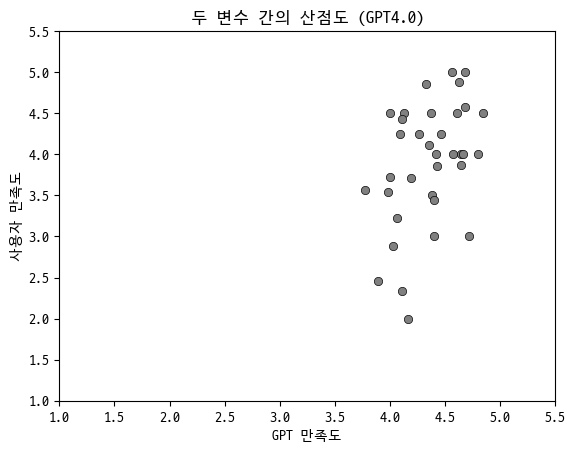

In [84]:
_=sns.scatterplot(x = df_B_con.iloc[:, 0], y = df_B_con.iloc[:, 1], color=['gray'], edgecolor=['black'])

# 축 및 제목 라벨링
plt.xlabel('X 축')
plt.ylabel('Y 축')
plt.title('두 변수 간의 산점도 (GPT4.0)')
plt.xlim(1.0, 5.5)
plt.ylim(1.0, 5.5)
plt.xlabel('GPT 만족도')
plt.ylabel('사용자 만족도')

# 그래프 표시
plt.show()

### A유형, B유형의 산점도

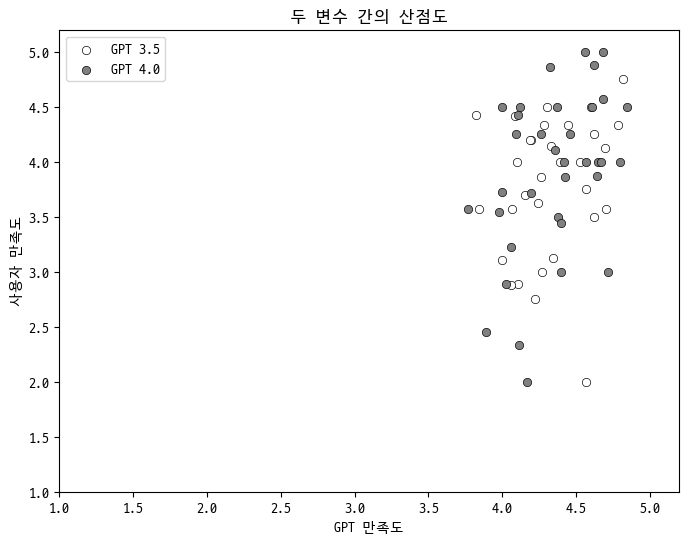

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

# 그림판 생성
plt.figure(figsize=(8, 6))

# 첫 번째 산점도 (GPT 3.5)
sns.scatterplot(x=df_A_con.iloc[:, 0], y=df_A_con.iloc[:, 1], color='white', edgecolor='black', label='GPT 3.5')

# 두 번째 산점도 (GPT 4.0)
sns.scatterplot(x=df_B_con.iloc[:, 0], y=df_B_con.iloc[:, 1], color='gray', edgecolor='black', label='GPT 4.0')

plt.title('두 변수 간의 산점도')
plt.xlim(1.0, 5.2)
plt.ylim(1.0, 5.2)
plt.xlabel('GPT 만족도')
plt.ylabel('사용자 만족도')
plt.legend()  # 범례 추가

plt.show()

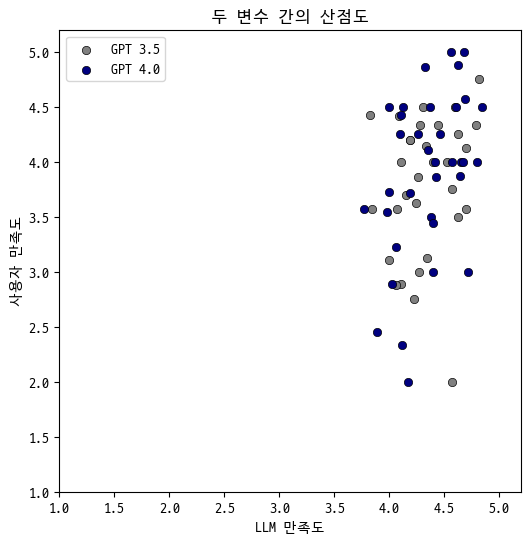

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager, rc

# 한글 폰트 설정
font_path = "C:/Users/SIZIAI/Downloads/D2Coding-Ver1.3.2-20180524/D2CodingAll/D2Coding-Ver1.3.2-20180524-all.ttc"
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

# 그림판 생성
plt.figure(figsize=(6, 6))

# 첫 번째 산점도 (GPT 3.5)
sns.scatterplot(x=df_A_con.iloc[:, 0], y=df_A_con.iloc[:, 1], color='gray', edgecolor='black', label='GPT 3.5')

# 두 번째 산점도 (GPT 4.0)
sns.scatterplot(x=df_B_con.iloc[:, 0], y=df_B_con.iloc[:, 1], color='navy', edgecolor='black', label='GPT 4.0')

plt.title('두 변수 간의 산점도')
plt.xlim(1.0, 5.2)
plt.ylim(1.0, 5.2)
plt.xlabel('LLM 만족도')
plt.ylabel('사용자 만족도')
plt.legend()  # 범례 추가

# 축의 비율을 동일하게 설정하여 정사각형으로 만들기
plt.gca().set_aspect('equal', adjustable='box')

# 그래프를 파일로 저장
plt.savefig("scatter_plot.png", format='png', dpi=300)  # .png 형식으로 저장
# plt.savefig("scatter_plot.jpg", format='jpg', dpi=300)  # .jpg 형식으로 저장을 원할 경우 주석 해제

plt.show()


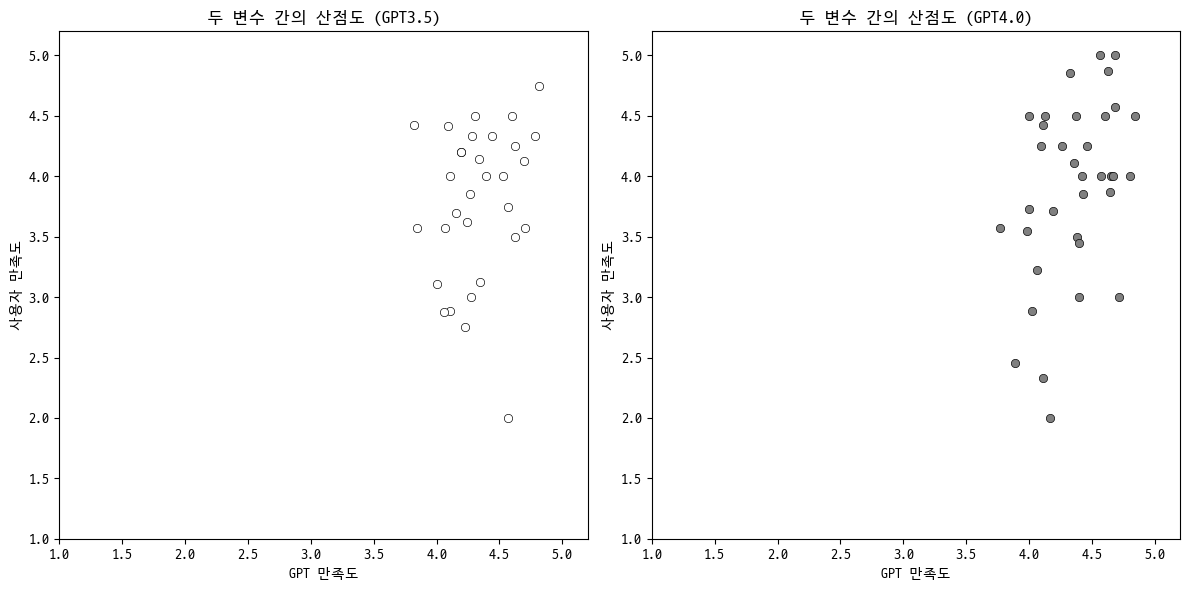

In [87]:
# 그래프를 나란히 그릴 그림 영역 생성
plt.rcParams['font.family'] = 'D2Coding'

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# 첫 번째 산점도 (GPT 3.5)
sns.scatterplot(x=df_A_con.iloc[:, 0], y=df_A_con.iloc[:, 1], color='white', edgecolor='black', ax=axs[0])
axs[0].set_title('두 변수 간의 산점도 (GPT3.5)')
axs[0].set_xlim(1.0, 5.2)
axs[0].set_ylim(1.0, 5.2)
axs[0].set_xlabel('GPT 만족도')
axs[0].set_ylabel('사용자 만족도')

# 두 번째 산점도 (GPT 4.0)
sns.scatterplot(x=df_B_con.iloc[:, 0], y=df_B_con.iloc[:, 1], color='gray', edgecolor='black', ax=axs[1])
axs[1].set_title('두 변수 간의 산점도 (GPT4.0)')
axs[1].set_xlim(1.0, 5.2)
axs[1].set_ylim(1.0, 5.2)
axs[1].set_xlabel('GPT 만족도')
axs[1].set_ylabel('사용자 만족도')

# 그래프 표시
plt.tight_layout()
plt.show()

## 종합 만족도 점수별 빈도수 그래프

In [123]:
df_A_survey = pd.read_excel('C:/Users/SIZIAI/SIAIZI/reserch/chatbot/carechat_2023/data/(A유형) 고민과 매칭된이야기 평가지(응답)의 폰번호제거.xlsx')
df_B_survey = pd.read_excel('C:/Users/SIZIAI/SIAIZI/reserch/chatbot/carechat_2023/data/(B유형) 고민과 매칭된이야기 평가지(응답)의 폰번호제거.xlsx')

### 설문자들의 종합만족도

In [89]:
A_akswhreh = df_A_survey.iloc[:, -7].value_counts().sort_index()

In [90]:
A_akswhreh

[1] 세 번의 매칭된이야기 사용 경험에 대한 종합 "만족도" 점수를 부탁드립니다.\n\n< 보기 >\n1점 : 완전 의미없음\n2점 : 별로 의미없음\n3점 : 중간\n4점 : 조금 의미있었음\n5점 : 완전 의미있었음
1      8
2     21
3     35
4    118
5     57
Name: count, dtype: int64

In [91]:
B_akswhreh = df_B_survey.iloc[:, -7].value_counts().sort_index()

In [92]:
B_akswhreh

[1] 세 번의 매칭된이야기 사용 경험에 대한 종합 "만족도" 점수를 부탁드립니다.\n\n< 보기 >\n1점 : 완전 의미없음\n2점 : 별로 의미없음\n3점 : 중간\n4점 : 조금 의미있었음\n5점 : 완전 의미있었음
1     13
2     15
3     35
4    111
5     80
Name: count, dtype: int64

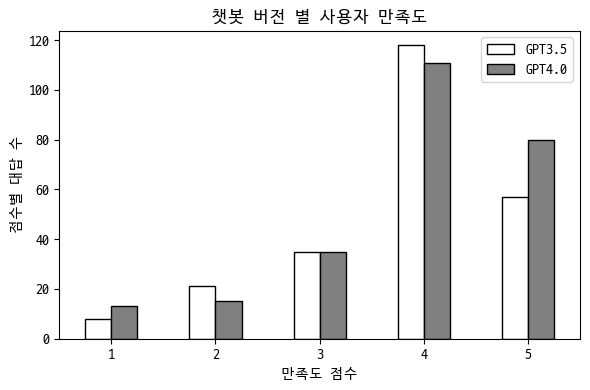

In [93]:
fig=plt.figure(figsize=(6, 4))
ax1=fig.subplots()

df1=pd.concat([A_akswhreh, B_akswhreh], axis=1)    # concat은 첫 column에 맞춰 index 정렬
df1.columns=['GPT3.5', 'GPT4.0']
_=df1.plot.bar(ax=ax1, color=['white', 'gray'], edgecolor=['black', 'black'])
plt.xticks(rotation=0)
plt.title('챗봇 버전 별 사용자 만족도')
plt.xlabel('만족도 점수')
plt.ylabel('점수별 대답 수')
fig.tight_layout()

### 챗봇이 설문자의 입장에서 평가한 종합 만족도

In [122]:
df_A_chat = pd.read_csv('C:/Users/SIZIAI/SIAIZI/reserch/chatbot/df_A_chat.csv')
df_B_chat = pd.read_csv('C:/Users/SIZIAI/SIAIZI/reserch/chatbot/df_B_chat.csv')

In [95]:
A_akswhreh = df_A_chat.iloc[:, -1].value_counts().sort_index()

In [96]:
A_akswhreh

score
1     57
2     39
3     53
4    533
5    686
Name: count, dtype: int64

In [97]:
B_akswhreh = df_B_chat.iloc[:, -1].value_counts().sort_index()

In [98]:
B_akswhreh

score
1     44
2      5
3     37
4    643
5    623
Name: count, dtype: int64

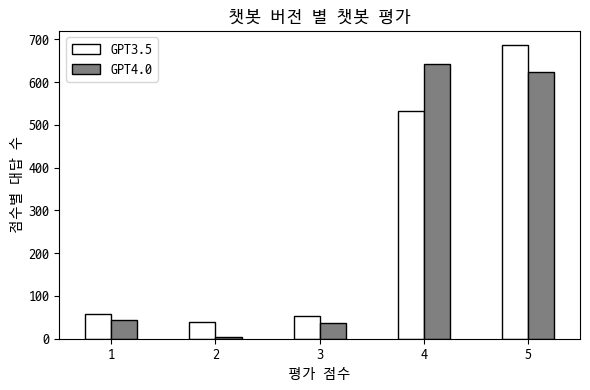

In [99]:
fig=plt.figure(figsize=(6, 4))
ax1=fig.subplots()

df1=pd.concat([A_akswhreh, B_akswhreh], axis=1)    # concat은 첫 column에 맞춰 index 정렬
df1.columns=['GPT3.5', 'GPT4.0']
_=df1.plot.bar(ax=ax1, color=['white', 'gray'], edgecolor=['black', 'black'])
plt.xticks(rotation=0)
plt.title('챗봇 버전 별 챗봇 평가')
plt.xlabel('평가 점수')
plt.ylabel('점수별 대답 수')
fig.tight_layout()

## 챗봇 이용 횟수

    설문지에 응답한 빈도수로 측정

### 유형A

In [127]:
df_A_count = pd.DataFrame(df_A_survey['이름'].value_counts())
df_A_count = df_A_count.value_counts().sort_index()
# new_value_counts = pd.Series([0,0,0,0,0,0], index=['3','6','11','13','14','15'])
# df_A_count = df_A_count.append(new_value_counts)
df_A_count.name = 'count_temp'
df_A_count

count
1         3
2         1
4         1
5         1
7         7
8        10
9         6
10        3
12        1
Name: count_temp, dtype: int64

In [131]:
df_A_count_df = df_A_count.reset_index()
# 컬럼 이름 변경
df_A_count_df.columns = ['이름', 'count']
df_A_count_df

,이름,count
0,1,3
1,2,1
2,4,1
3,5,1
4,7,7
5,8,10
6,9,6
7,10,3
8,12,1


Text(0, 0.5, '사용자 수')

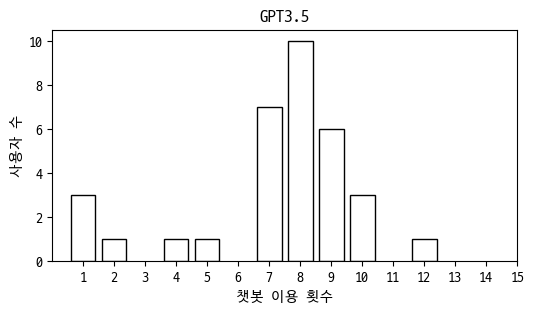

In [132]:
fig=plt.figure(figsize=(6, 3))
ax1=fig.subplots()
_=plt.bar(df_A_count_df['이름'], df_A_count_df['count'], color=['white'], edgecolor=['black'])
plt.xticks(range(1,16))
plt.title('GPT3.5')
plt.xlabel('챗봇 이용 횟수')
plt.ylabel('사용자 수')

### 유형B

In [133]:
df_B_count = pd.DataFrame(df_B_survey['이름'].value_counts())
df_B_count = df_B_count.value_counts().sort_index()
df_B_count.name = 'count_temp'
df_B_count

count
1        3
2        5
7        8
8        9
9        5
10       2
11       3
15       1
Name: count_temp, dtype: int64

In [134]:
df_B_count_df = df_B_count.reset_index()
# 컬럼 이름 변경
df_B_count_df.columns = ['이름', 'count']
df_B_count_df

,이름,count
0,1,3
1,2,5
2,7,8
3,8,9
4,9,5
5,10,2
6,11,3
7,15,1


Text(0, 0.5, '사용자 수')

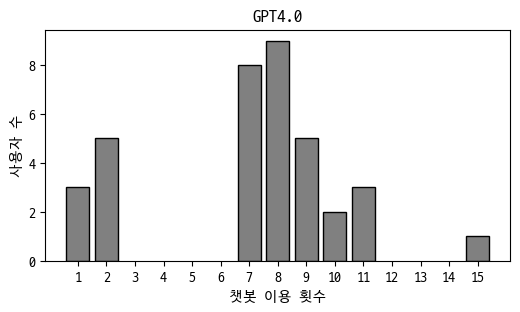

In [135]:
fig=plt.figure(figsize=(6, 3))
ax1=fig.subplots()
_=plt.bar(df_B_count_df['이름'], df_B_count_df['count'], color=['gray'], edgecolor=['black'])
plt.xticks(range(1,16))
plt.title('GPT4.0')
plt.xlabel('챗봇 이용 횟수')
plt.ylabel('사용자 수')

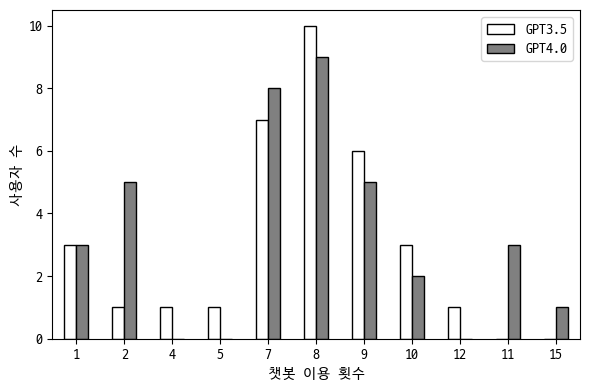

In [137]:
fig=plt.figure(figsize=(6, 4))
ax1=fig.subplots()

df_A_count_df.set_index('이름', inplace=True)
df_B_count_df.set_index('이름', inplace=True)

df1=pd.concat([df_A_count_df, df_B_count_df], axis=1)    # concat은 첫 column에 맞춰 index 정렬
df1.columns=['GPT3.5', 'GPT4.0']
_=df1.plot.bar(ax=ax1, color=['white', 'gray'], edgecolor=['black', 'black'])
plt.xticks(rotation=0)
plt.xlabel('챗봇 이용 횟수')
plt.ylabel('사용자 수')
fig.tight_layout()

## 주관식 만족응답 주관식 불만족 응답 한 개라도 대답한 사람 수

In [115]:
df_A_survey_cleaned = df_A_survey.dropna(subset=['주관식 –  만족의 이유 작성해주시기로 선택하신 분은 작성 부탁드립니다.', '주관식 – 불만족의 이유를 작성해주시기로 선택하신 분은 작성 부탁드립니다.'], how='all')
df_akswhrehdlfma = df_A_survey_cleaned.iloc[:, [1, -1, -3]]
len(df_akswhrehdlfma['이름'].unique())

27

In [116]:
df_B_survey_cleaned = df_B_survey.dropna(subset=['주관식 –  만족의 이유 작성해주시기로 선택하신 분은 작성 부탁드립니다.', '주관식 – 불만족의 이유를 작성해주시기로 선택하신 분은 작성 부탁드립니다.'], how='all')
df_akswhrehdlfma_B = df_B_survey_cleaned.iloc[:, [1, -1, -3]]
len(df_akswhrehdlfma_B['이름'].unique())

32